In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

In [2]:
# Load Dataset
df = pd.read_csv("data.csv")

# Drop unnecessary columns
df.drop(["id", "Unnamed: 32"], axis=1, inplace=True)

# Convert target column
df["diagnosis"] = df["diagnosis"].map({"M":1, "B":0})

# Features and Target
X = df.drop("diagnosis", axis=1)
y = df["diagnosis"]

In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [4]:
# Standardization
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [5]:
# Logistic Regression Model
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [6]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:,1]

In [7]:
print("Confusion Matrix")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report")
print(classification_report(y_test, y_pred))

print("\nROC-AUC Score")
print(roc_auc_score(y_test, y_prob))

Confusion Matrix
[[70  1]
 [ 2 41]]

Classification Report
              precision    recall  f1-score   support

           0       0.97      0.99      0.98        71
           1       0.98      0.95      0.96        43

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114


ROC-AUC Score
0.99737962659679


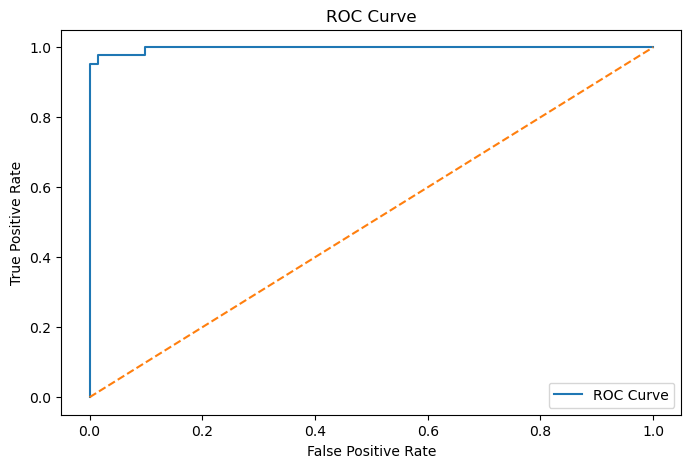

In [8]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(8,5))
plt.plot(fpr, tpr, label="ROC Curve")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

In [9]:
threshold = 0.3

custom_pred = (y_prob >= threshold).astype(int)

print(confusion_matrix(y_test, custom_pred))

[[67  4]
 [ 1 42]]
